# import

In [1]:
import argparse
import os
import copy
import sys

import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont
from torchvision.ops import box_convert

# Grounding DINO
import GroundingDINO.groundingdino.datasets.transforms as T
from GroundingDINO.groundingdino.models import build_model
from GroundingDINO.groundingdino.util import box_ops
from GroundingDINO.groundingdino.util.slconfig import SLConfig
from GroundingDINO.groundingdino.util.utils import clean_state_dict, get_phrases_from_posmap
from GroundingDINO.groundingdino.util.inference import annotate, load_image, predict

import supervision as sv

# segment anything
base_path = r"C:\\Users\\test\\kwangwoon\\2024_1\\산학연계\\image_searching\segment-anything"

# 경로를 sys.path에 추가
if base_path not in sys.path:
    sys.path.append(base_path)

from segment_anything import build_sam, SamPredictor 
import cv2
import numpy as np
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

# embedding / vector DB
import clip
import psycopg2

c:\Users\test\.conda\envs\designovel2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(torch.__version__)
print(torch.cuda.is_available())

2.3.1+cu121
True


# Grounded SAM

In [3]:
def load_model_hf(repo_id, filename, ckpt_config_filename, device='cpu'):
    cache_config_file = hf_hub_download(repo_id=repo_id, filename=ckpt_config_filename)

    args = SLConfig.fromfile(cache_config_file) 
    model = build_model(args)
    args.device = device

    cache_file = hf_hub_download(repo_id=repo_id, filename=filename)
    checkpoint = torch.load(cache_file, map_location='cpu')
    log = model.load_state_dict(clean_state_dict(checkpoint['model']), strict=False)
    print("Model loaded from {} \n => {}".format(cache_file, log))
    _ = model.eval()
    return model  

In [4]:
ckpt_repo_id = "ShilongLiu/GroundingDINO"
ckpt_filenmae = "groundingdino_swinb_cogcoor.pth"
ckpt_config_filename = "GroundingDINO_SwinB.cfg.py"

In [5]:
groundingdino_model = load_model_hf(ckpt_repo_id, ckpt_filenmae, ckpt_config_filename)

final text_encoder_type: bert-base-uncased
Model loaded from C:\Users\test\.cache\huggingface\hub\models--ShilongLiu--GroundingDINO\snapshots\a94c9b567a2a374598f05c584e96798a170c56fb\groundingdino_swinb_cogcoor.pth 
 => _IncompatibleKeys(missing_keys=[], unexpected_keys=['label_enc.weight', 'bert.embeddings.position_ids'])


In [6]:
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(DEVICE)
sam_checkpoint = 'sam_vit_h_4b8939.pth'
sam = build_sam(checkpoint=sam_checkpoint)
sam.to(device=DEVICE)
sam_predictor = SamPredictor(sam)

cuda:0


## 함수 정의

In [7]:
# grounding DINO로 box detection
def detect(image, text_prompt, model, image_source, box_threshold = 0.3, text_threshold = 0.25):
  boxes, logits, phrases = predict(
      model=model, 
      image=image, 
      caption=text_prompt,
      box_threshold=box_threshold,
      text_threshold=text_threshold,
      device=DEVICE
  )
  
  annotated_frame = annotate(image_source=image_source, boxes=boxes, logits=logits, phrases=phrases)
  annotated_frame = annotated_frame[...,::-1] # BGR to RGB 

  return boxes, annotated_frame


# 얻은 박스를 프롬프트로 활용하여 SAM 적용
def segment(image, sam_model, boxes):
  sam_model.set_image(image)
  H, W, _ = image.shape
  boxes_xyxy = box_ops.box_cxcywh_to_xyxy(boxes) * torch.Tensor([W, H, W, H])

  transformed_boxes = sam_model.transform.apply_boxes_torch(boxes_xyxy.to(DEVICE), image.shape[:2])
  masks, _, _ = sam_model.predict_torch(
      point_coords = None,
      point_labels = None,
      boxes = transformed_boxes,
      multimask_output = False,
      )
  return masks.cpu()


# 상품 크기에 맞추어 이미지 crop
def apply_mask_to_image(image, mask):
    # 마스크된 부분만을 원본 이미지에 적용합니다.
    masked_image = image.copy()
    masked_image[mask == 0] = [255, 255, 255]

    masked_indices = np.where(mask != 0)

    # 마스크된 부분의 최소 및 최대 y, x 좌표를 찾습니다.
    min_y, min_x = np.min(masked_indices, axis=1)
    max_y, max_x = np.max(masked_indices, axis=1)

    # 마스크된 부분만을 포함하는 새로운 이미지 생성
    masked_region_only = masked_image[min_y:max_y+1, min_x:max_x+1, :]

    return masked_region_only



# 시뮬레이션

## input 이미지에 Grounded SAM 적용

In [96]:
# 입력된 이미지와 프롬프트(카테고리)
input_image_path = 'assets/피그먼트 스웨트셔츠_SPMWE23C20_전신.jpg'
prompt = 'sweat/shirts'
image_source, image = load_image(input_image_path)

In [97]:
# grounded SAM pipeline
def SAM(prompt, image_source):
    detected_boxes, annotated_frame = detect(image, prompt, image_source=image_source, model=groundingdino_model)
    segmented_frame_masks = segment(image_source, sam_predictor, boxes=detected_boxes)
    masked_region_only = apply_mask_to_image(image_source, segmented_frame_masks[0][0])
    return masked_region_only, annotated_frame

In [98]:
sam_image, annotated_frame = SAM(prompt, image_source)

SupervisionWarnings: annotate is deprecated: `BoxAnnotator` is deprecated and will be removed in `supervision-0.22.0`. Use `BoundingBoxAnnotator` and `LabelAnnotator` instead


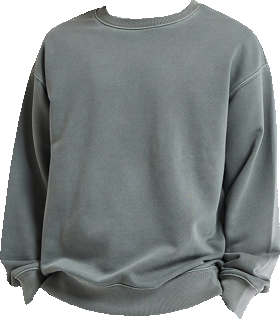

In [99]:
sam_image = Image.fromarray(sam_image)
sam_image

## CLIP으로 임베딩

In [100]:
model, preprocess = clip.load('ViT-B/32', device=DEVICE)

In [101]:
preprocessed_image = preprocess(sam_image).unsqueeze(0).to(DEVICE)

In [102]:
with torch.no_grad():
    input_feature = model.encode_image(preprocessed_image)
    
feature_numpy = input_feature.cpu().numpy().tolist()

In [108]:
def find_most_similar_image(input_feature):
    # 데이터베이스 연결 설정
    conn = psycopg2.connect("dbname=imagevector user=test password=5303 host=localhost")
    cur = conn.cursor()

    # 벡터 유사도 계산 쿼리 실행
    # input_feature는 이미 일차원 리스트
    cur.execute("""
        SELECT id, embedding <-> %s::vector AS distance
        FROM items
        ORDER BY distance ASC
        LIMIT 5; 
    """, (input_feature, ))  # 리스트를 튜플 안에 넣어 전달

    # 결과를 모두 가져오기
    results = cur.fetchall()
    if results:
        print("Top similar images:")
        for result in results:
            print(f"Image ID: {result[0]}, Similarity Score: {result[1]}")
    else:
        print("No similar images found.")

    # 연결 종료
    cur.close()
    conn.close()


In [109]:
find_most_similar_image(feature_numpy[0])

Top similar images:
Image ID: 1, Similarity Score: 3.8470888600529562
Image ID: 5, Similarity Score: 4.106290058190262
Image ID: 4, Similarity Score: 6.348187477771091
Image ID: 2, Similarity Score: 6.4871681907635095
Image ID: 3, Similarity Score: 7.825285436524724
